# 🏠 Indoor Scene Classification Using Transfer Learning

## Project Overview

In this project, we will build an Indoor Scene Classification model using
Transfer Learning.

The dataset contains images belonging to multiple indoor scene categories.

Instead of training a Convolutional Neural Network completely from scratch,
we will use a pretrained CNN that has already learned useful visual features
from the ImageNet dataset.

We will use **EfficientNetB0** as our pretrained model and adapt it to our
Indoor Scene Classification problem.

The project will cover:

- Dataset preparation
- Image preprocessing
- Data visualization
- Data augmentation
- Transfer Learning
- Feature Extraction
- Fine-Tuning
- Model evaluation
- Confusion Matrix
- Classification Report
- Single-image prediction
- Top-5 predictions
- Model saving
- Comparison with CNN trained from scratch

## What is Transfer Learning?

Transfer Learning is a Deep Learning technique where we reuse knowledge
learned by a model on one large dataset and apply that knowledge to another
related problem.

For example, a CNN trained on ImageNet has already learned many useful visual
features such as:

- Edges
- Lines
- Textures
- Shapes
- Patterns
- Object parts
- Complex visual structures

Instead of learning all these features from random weights, we can reuse
them for our Indoor Scene Classification task.

The general idea is:

```text
Large Dataset
     ↓
Pretrained CNN
     ↓
Learned Visual Features
     ↓
Our Indoor Dataset
     ↓
New Classification Head
     ↓
Indoor Scene Prediction


---

# Cell — Markdown

```markdown
## Feature Extraction vs Fine-Tuning

Transfer Learning commonly uses two important approaches.

### Feature Extraction

In Feature Extraction, we freeze the pretrained CNN.

The pretrained layers do not update their weights.

Only our newly added classification layers are trained.

```text
Pretrained CNN
     ↓
Frozen
     ↓
Feature Extraction
     ↓
New Classification Head
     ↓
Training

In [1]:
# Import required libraries

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import seaborn as sns

print("TensorFlow Version:", tf.__version__)
print("GPU Devices:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.21.0
GPU Devices: []


## Dataset Location

Our dataset is stored in the following directory:

```text
F:\Anas\Dataset\Object_Data

In [2]:
# Main dataset directory

dataset_path = Path(r"F:\Anas\Dataset\Object_Data")

print("Dataset Path:")
print(dataset_path)

print("\nContents:")

for item in dataset_path.iterdir():
    print(item.name)

Dataset Path:
F:\Anas\Dataset\Object_Data

Contents:
indoorCVPR_09
indoorCVPR_09annotations
TestImages.txt
TrainImages.txt


In [3]:
# Create important dataset paths

image_path = dataset_path / "indoorCVPR_09" / "Images"

train_file = dataset_path / "TrainImages.txt"
test_file = dataset_path / "TestImages.txt"

print("Image Directory:", image_path)
print("Training File:", train_file)
print("Testing File:", test_file)

Image Directory: F:\Anas\Dataset\Object_Data\indoorCVPR_09\Images
Training File: F:\Anas\Dataset\Object_Data\TrainImages.txt
Testing File: F:\Anas\Dataset\Object_Data\TestImages.txt


In [4]:
# Verify that the required paths exist

print("Image directory exists:", image_path.exists())
print("Training file exists:", train_file.exists())
print("Testing file exists:", test_file.exists())

Image directory exists: True
Training file exists: True
Testing file exists: True


## Exploring the Dataset Classes

Each indoor scene category is represented by a separate folder.

For example:

```text
Images
│
├── airport_inside
├── artstudio
├── bakery
├── bar
├── bedroom
├── bookstore
├── ...

In [5]:
# Detect class names automatically

classes = sorted([
    folder.name
    for folder in image_path.iterdir()
    if folder.is_dir()
])

NUM_CLASSES = len(classes)

print("Number of classes:", NUM_CLASSES)

print("\nClasses:")

for index, class_name in enumerate(classes):
    print(f"{index}: {class_name}")

Number of classes: 67

Classes:
0: airport_inside
1: artstudio
2: auditorium
3: bakery
4: bar
5: bathroom
6: bedroom
7: bookstore
8: bowling
9: buffet
10: casino
11: children_room
12: church_inside
13: classroom
14: cloister
15: closet
16: clothingstore
17: computerroom
18: concert_hall
19: corridor
20: deli
21: dentaloffice
22: dining_room
23: elevator
24: fastfood_restaurant
25: florist
26: gameroom
27: garage
28: greenhouse
29: grocerystore
30: gym
31: hairsalon
32: hospitalroom
33: inside_bus
34: inside_subway
35: jewelleryshop
36: kindergarden
37: kitchen
38: laboratorywet
39: laundromat
40: library
41: livingroom
42: lobby
43: locker_room
44: mall
45: meeting_room
46: movietheater
47: museum
48: nursery
49: office
50: operating_room
51: pantry
52: poolinside
53: prisoncell
54: restaurant
55: restaurant_kitchen
56: shoeshop
57: stairscase
58: studiomusic
59: subway
60: toystore
61: trainstation
62: tv_studio
63: videostore
64: waitingroom
65: warehouse
66: winecellar


## Creating a Class-to-Index Mapping

Neural networks work with numerical labels rather than text labels.

Therefore, we convert each class name into an integer.

For example:

```text
airport_inside → 0
artstudio       → 1
bakery          → 2
bar             → 3
...

In [6]:
# Create mappings

class_to_index = {
    class_name: index
    for index, class_name in enumerate(classes)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

print("Example mapping:")
print(list(class_to_index.items())[:10])

Example mapping:
[('airport_inside', 0), ('artstudio', 1), ('auditorium', 2), ('bakery', 3), ('bar', 4), ('bathroom', 5), ('bedroom', 6), ('bookstore', 7), ('bowling', 8), ('buffet', 9)]


## Reading the Training and Testing Files

The dataset provides two text files:

- `TrainImages.txt`
- `TestImages.txt`

These files contain relative image paths.

For example:

```text
gameroom/bt_132294gameroom2.jpg

In [7]:
def create_dataframe(file_path):
    rows = []

    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            relative_path = line.strip()

            if not relative_path:
                continue

            relative_path = Path(relative_path)

            class_name = relative_path.parts[0]
            full_path = image_path / relative_path

            if full_path.exists():
                rows.append({
                    "image_path": str(full_path),
                    "class_name": class_name,
                    "label": class_to_index[class_name]
                })

    return pd.DataFrame(rows)

In [8]:
# Create training and testing DataFrames

train_df = create_dataframe(train_file)
test_df = create_dataframe(test_file)

print("Training images:", len(train_df))
print("Testing images:", len(test_df))

train_df.head()

Training images: 5360
Testing images: 1340


,image_path,class_name,label
0,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,gameroom,26
1,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,poolinside,52
2,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,winecellar,66
3,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,casino,10
4,F:\Anas\Dataset\Object_Data\indoorCVPR_09\Imag...,livingroom,41


## Checking the Dataset

Before training a neural network, we should inspect our data.

We will check:

- Number of images
- Number of classes
- Missing values
- Class distribution
- Image paths

In [9]:
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nTraining classes:")
print(train_df["class_name"].nunique())

print("\nTesting classes:")
print(test_df["class_name"].nunique())

Training shape: (5360, 3)
Testing shape: (1340, 3)

Missing values:
image_path    0
class_name    0
label         0
dtype: int64

Training classes:
67

Testing classes:
67


## Creating the Validation Set

The original dataset provides training and testing images.

We will divide the training data into:

```text
Training Data
     ↓
 ┌───┴────┐
 ↓        ↓
Train   Validation

In [10]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

Training images: 4288
Validation images: 1072
Testing images: 1340


## Class Distribution

A balanced dataset is generally easier for a classifier to learn.

We will visualize the number of training images in each class.

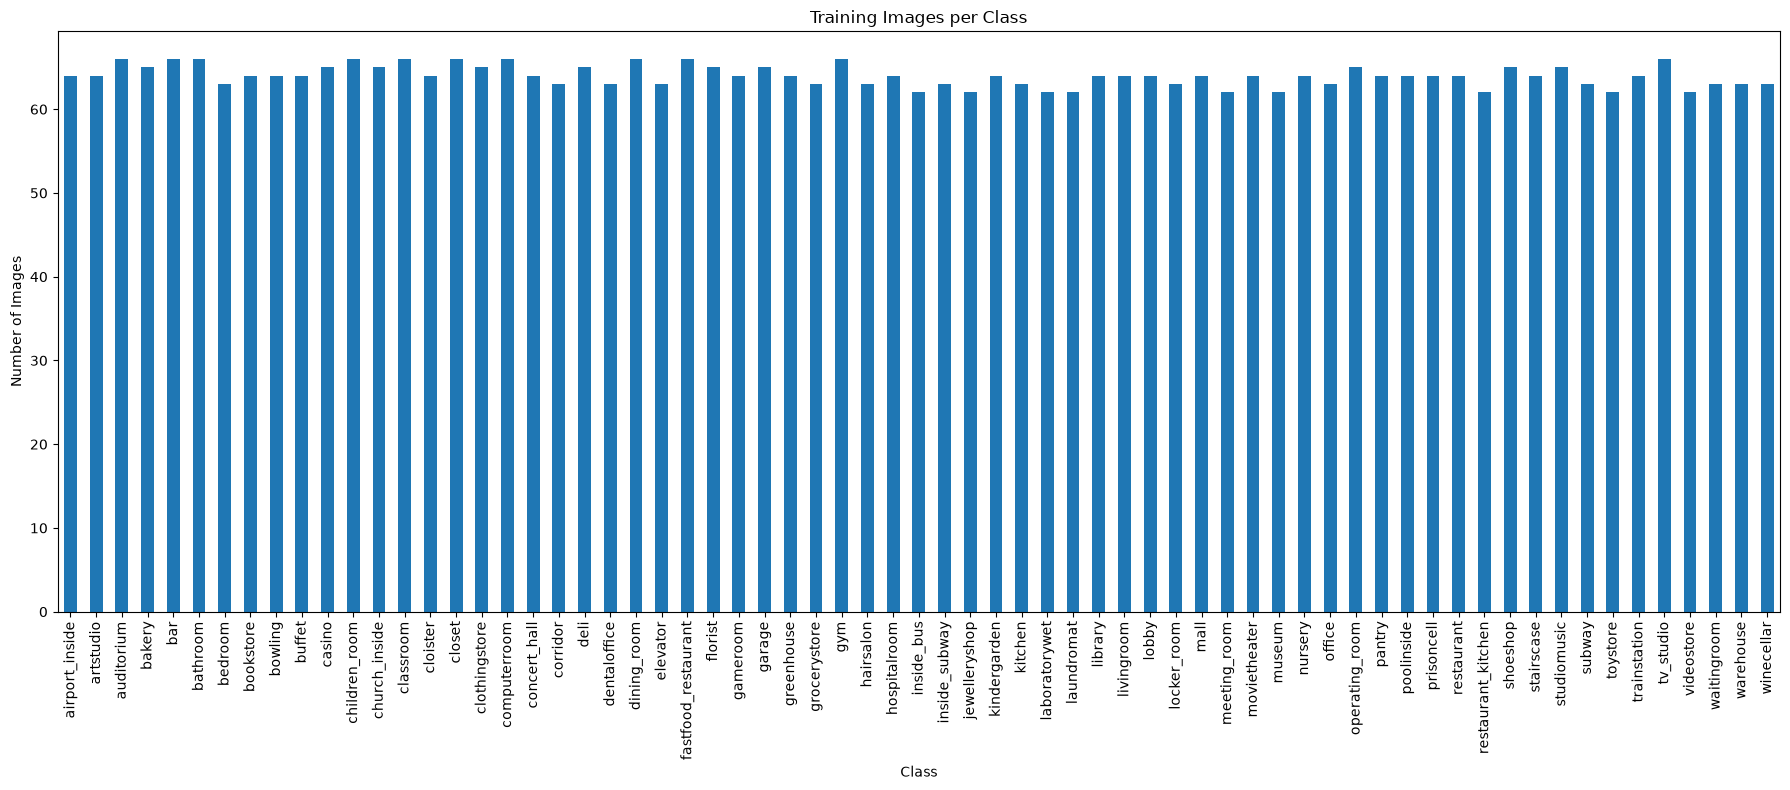

In [11]:
plt.figure(figsize=(18, 8))

train_df["class_name"].value_counts().sort_index().plot(kind="bar")

plt.title("Training Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Visualizing Sample Images

Before training, it is important to visually inspect the images.

This helps us verify that:

- Images are loading correctly
- Labels match the images
- Images contain useful visual information
- There are no obvious corrupted files

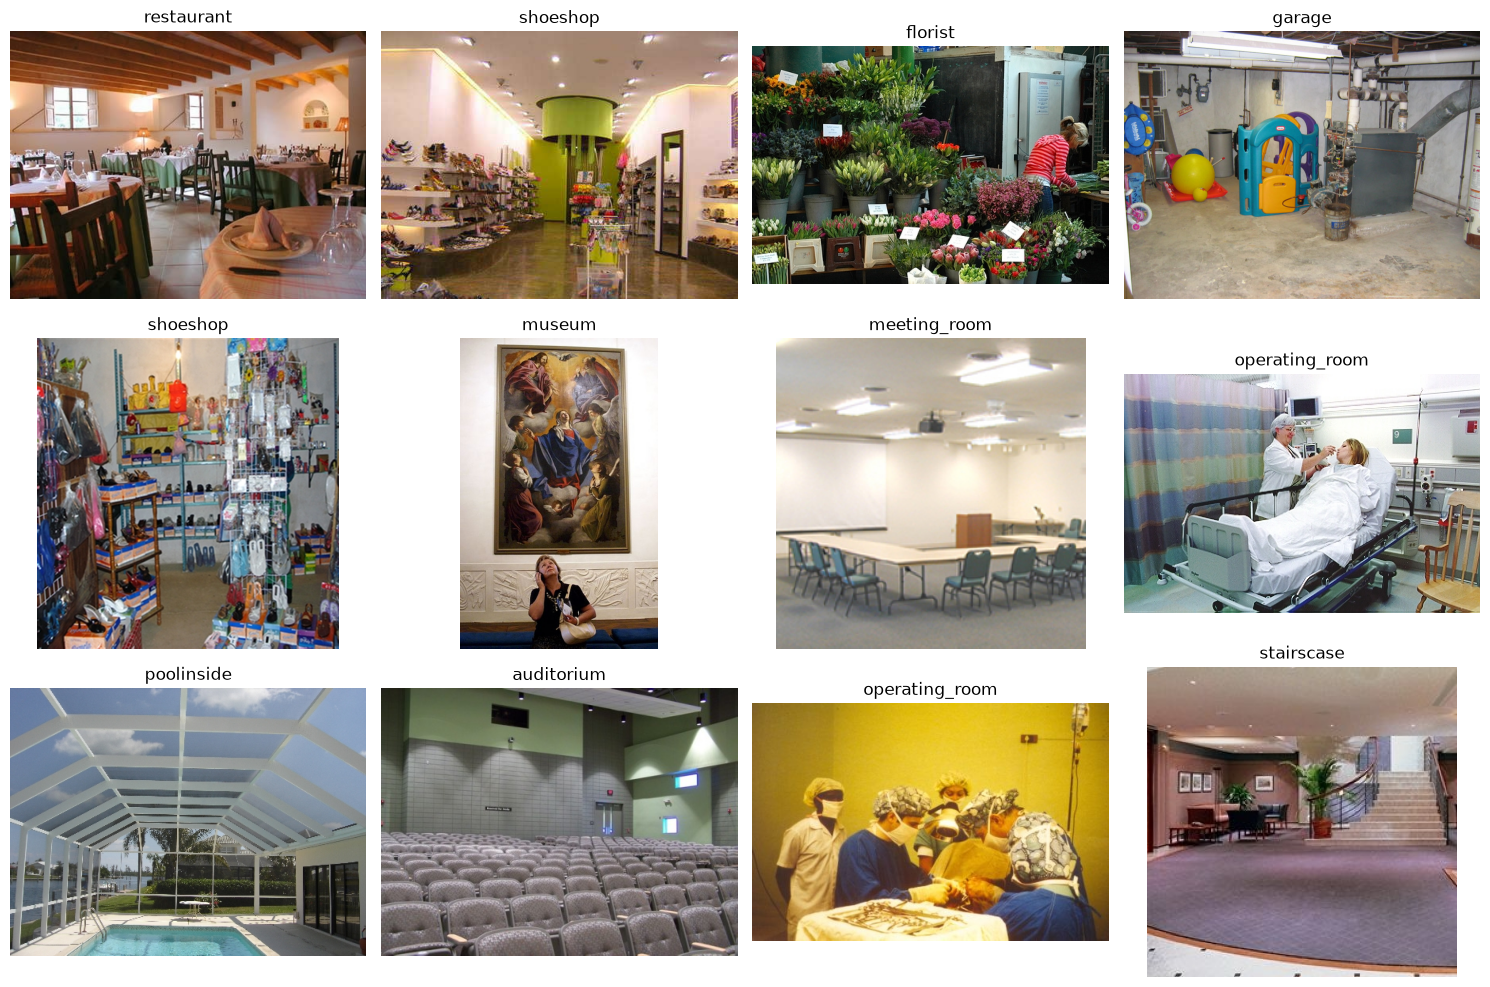

In [12]:
# Display random sample images

sample_df = train_df.sample(12, random_state=42)

plt.figure(figsize=(15, 10))

for i, (_, row) in enumerate(sample_df.iterrows()):

    image = Image.open(row["image_path"]).convert("RGB")

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(row["class_name"])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Image Size and Format

The original dataset may contain images with different dimensions and,
in some cases, files whose extension does not perfectly represent their
underlying image format.

For this reason, we use PIL to safely open the images.

All images will be:

- Converted to RGB
- Resized to 224 × 224
- Converted to floating-point values

In [13]:
# Image configuration

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print("Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)

Image Size: (224, 224)
Batch Size: 32


## Image Preprocessing

Our image loader performs the following operations:

```text
Image
  ↓
PIL
  ↓
RGB
  ↓
Resize to 224 × 224
  ↓
Convert to NumPy
  ↓
Convert to TensorFlow Tensor

In [14]:
def load_image(image_path, label):

    def read_with_pil(path):

        path = path.numpy().decode("utf-8")

        image = Image.open(path).convert("RGB")

        image = image.resize(IMG_SIZE)

        image = np.array(
            image,
            dtype=np.float32
        )

        return image

    image = tf.py_function(
        func=read_with_pil,
        inp=[image_path],
        Tout=tf.float32
    )

    image.set_shape([
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    ])

    return image, label

## Creating TensorFlow Datasets

TensorFlow's `tf.data` API provides an efficient way to load and process
images.

We will use:

- `shuffle()` for training data
- `map()` for image preprocessing
- `batch()` for mini-batch training
- `prefetch()` to improve the input pipeline

In [15]:
def create_dataset(df, shuffle=False):

    paths = df["image_path"].values
    labels = df["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=42
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [16]:
# Create datasets

train_dataset = create_dataset(
    train_df,
    shuffle=True
)

val_dataset = create_dataset(
    val_df,
    shuffle=False
)

test_dataset = create_dataset(
    test_df,
    shuffle=False
)

print("Datasets created successfully.")

Datasets created successfully.


In [17]:
# Inspect one batch

images, labels = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Minimum pixel value:", tf.reduce_min(images).numpy())
print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Minimum pixel value: 0.0
Maximum pixel value: 255.0


## Data Augmentation

Deep Learning models can overfit when they repeatedly see the same training
images.

Data augmentation creates slightly different versions of training images.

We will use:

- Random horizontal flipping
- Random rotation
- Random zoom

These transformations are applied during training and help the model learn
more robust visual features.

In [18]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1)
])

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


## Understanding EfficientNetB0

EfficientNet is a family of CNN architectures designed to achieve a good
balance between accuracy and computational efficiency.

We will use **EfficientNetB0** because it is relatively lightweight and is
a good model for learning Transfer Learning.

We will load weights pretrained on ImageNet.

```text
ImageNet
   ↓
EfficientNetB0
   ↓
Pretrained Visual Features
   ↓
Our Indoor Dataset

In [19]:
# Load pretrained EfficientNetB0

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

print("EfficientNetB0 loaded successfully.")

EfficientNetB0 loaded successfully.


## Freezing the Pretrained Model

At the beginning, we freeze the pretrained EfficientNetB0 layers.

This means their weights will not be changed during the first training phase.

Only our newly added classification layers will learn.

This stage is called **Feature Extraction**.

In [20]:
base_model.trainable = False

print("Base model trainable:", base_model.trainable)

Base model trainable: False


## Building the Transfer Learning Model

Our architecture will be:

```text
Input Image
     ↓
Data Augmentation
     ↓
EfficientNetB0
     ↓
Global Average Pooling
     ↓
Dense Layer
     ↓
Dropout
     ↓
67-Class Softmax

In [21]:
inputs = keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = keras.layers.GlobalAveragePooling2D()(x)

x = keras.layers.Dense(
    256,
    activation="relu"
)(x)

x = keras.layers.Dropout(0.3)(x)

outputs = keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 67)             │        17,219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,394,726 (16.76 MB)

 Trainable params: 345,155 (1.32 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Why Global Average Pooling?

The pretrained CNN produces feature maps.

Global Average Pooling converts these feature maps into a compact feature
vector.

Instead of using a very large Flatten layer, Global Average Pooling reduces
the number of trainable parameters.

This can help reduce overfitting and makes the model more efficient.

## Compiling the Model

We use:

### Optimizer

Adam is used to update the trainable weights.

### Loss Function

Because this is a multi-class classification problem and our labels are
integer encoded, we use:

`sparse_categorical_crossentropy`

### Metric

Accuracy tells us the percentage of correctly classified images.

In [22]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Training Callbacks

Callbacks allow us to control training automatically.

We will use:

**EarlyStopping**

Stops training when validation performance stops improving.

**ModelCheckpoint**

Saves the best model.

**ReduceLROnPlateau**

Reduces the learning rate when validation loss stops improving.

In [23]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ModelCheckpoint(
        "best_efficientnet_feature_extraction.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

## Feature Extraction Training

During this phase:

```text
EfficientNetB0 → Frozen
Classification Head → Trainable

In [24]:
history_feature = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15


f:\Anas\DATA_SCIENCE_POTPOLIO\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


134/134 ━━━━━━━━━━━━━━━━━━━━ 52s 354ms/step - accuracy: 0.3431 - loss: 2.7208 - val_accuracy: 0.6250 - val_loss: 1.3846 - learning_rate: 0.0010
Epoch 2/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 47s 349ms/step - accuracy: 0.5802 - loss: 1.4798 - val_accuracy: 0.6912 - val_loss: 1.0806 - learning_rate: 0.0010
Epoch 3/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 48s 355ms/step - accuracy: 0.6649 - loss: 1.1791 - val_accuracy: 0.7127 - val_loss: 0.9929 - learning_rate: 0.0010
Epoch 4/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 47s 352ms/step - accuracy: 0.7111 - loss: 0.9860 - val_accuracy: 0.7229 - val_loss: 0.9282 - learning_rate: 0.0010
Epoch 5/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 47s 351ms/step - accuracy: 0.7435 - loss: 0.8873 - val_accuracy: 0.7323 - val_loss: 0.9071 - learning_rate: 0.0010
Epoch 6/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 47s 349ms/step - accuracy: 0.7668 - loss: 0.7833 - val_accuracy: 0.7164 - val_loss: 0.9174 - learning_rate: 0.0010
Epoch 7/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 46s 344ms/step - accuracy: 0.7910 - loss:

## Visualizing Feature Extraction Training

We will plot:

- Training accuracy
- Validation accuracy
- Training loss
- Validation loss

These plots help us understand whether the model is learning or overfitting.

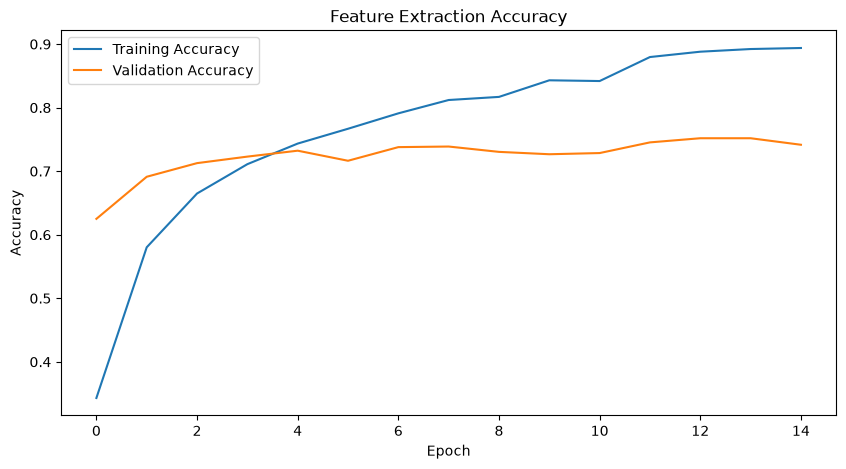

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_feature.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_feature.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Feature Extraction Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

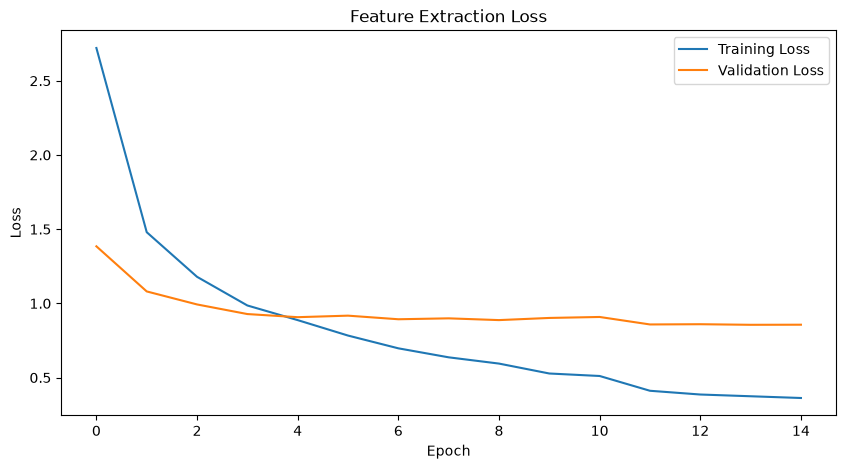

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_feature.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_feature.history["val_loss"],
    label="Validation Loss"
)

plt.title("Feature Extraction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Evaluating Feature Extraction

Before fine-tuning, we evaluate the model on the test dataset.

This gives us a baseline for comparison.

In [27]:
feature_test_loss, feature_test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print(
    f"Feature Extraction Test Accuracy: "
    f"{feature_test_accuracy * 100:.2f}%"
)

42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 268ms/step - accuracy: 0.7321 - loss: 0.8642
Feature Extraction Test Accuracy: 73.21%


## Fine-Tuning

The first stage has taught the new classification head how to use the
pretrained features.

Now we can allow some of the later EfficientNet layers to learn from our
Indoor Scene dataset.

We will:

- Unfreeze EfficientNet
- Keep earlier layers frozen
- Unfreeze the later layers
- Use a very small learning rate
- Recompile the model

In [28]:
# Unfreeze the base model

base_model.trainable = True

# Freeze earlier layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(
    "Total base model layers:",
    len(base_model.layers)
)

print(
    "Trainable base model layers:",
    sum(
        layer.trainable
        for layer in base_model.layers
    )
)

Total base model layers: 238
Trainable base model layers: 30


## Why Use a Small Learning Rate?

During the first training stage, the pretrained model is frozen.

During fine-tuning, we start changing pretrained weights.

If we use a large learning rate, the model may change those useful pretrained
weights too aggressively.

Therefore, we use a much smaller learning rate such as:

```text
0.001  → Feature Extraction

0.00001 → Fine-Tuning

In [29]:
# Recompile after changing trainable layers

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


## Fine-Tuning Training

Now the later EfficientNet layers and our classification head can adapt to
the Indoor Scene Classification problem.

In [30]:
fine_tune_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ModelCheckpoint(
        "best_efficientnet_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]

In [31]:
history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=fine_tune_callbacks
)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 62s 414ms/step - accuracy: 0.6003 - loss: 1.5937 - val_accuracy: 0.7062 - val_loss: 1.0596 - learning_rate: 1.0000e-05
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 55s 412ms/step - accuracy: 0.6467 - loss: 1.3837 - val_accuracy: 0.6782 - val_loss: 1.1643 - learning_rate: 1.0000e-05
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 56s 416ms/step - accuracy: 0.7027 - loss: 1.2147 - val_accuracy: 0.6819 - val_loss: 1.1640 - learning_rate: 1.0000e-05
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 54s 405ms/step - accuracy: 0.7262 - loss: 1.1307 - val_accuracy: 0.6772 - val_loss: 1.1708 - learning_rate: 2.0000e-06
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 53s 395ms/step - accuracy: 0.7104 - loss: 1.1246 - val_accuracy: 0.6791 - val_loss: 1.1577 - learning_rate: 2.0000e-06
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 53s 394ms/step - accuracy: 0.7264 - loss: 1.0973 - val_accuracy: 0.6791 - val_loss: 1.1557 - learning_rate: 4.0000e-07


## Fine-Tuning Training Curves

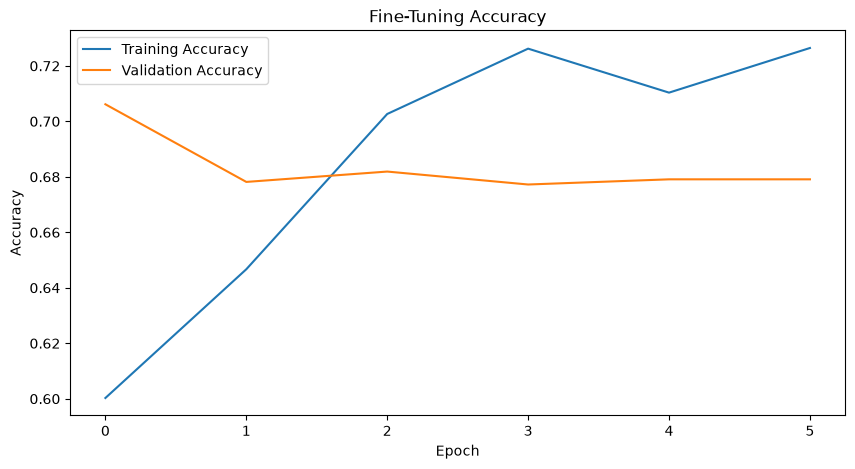

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_fine.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_fine.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

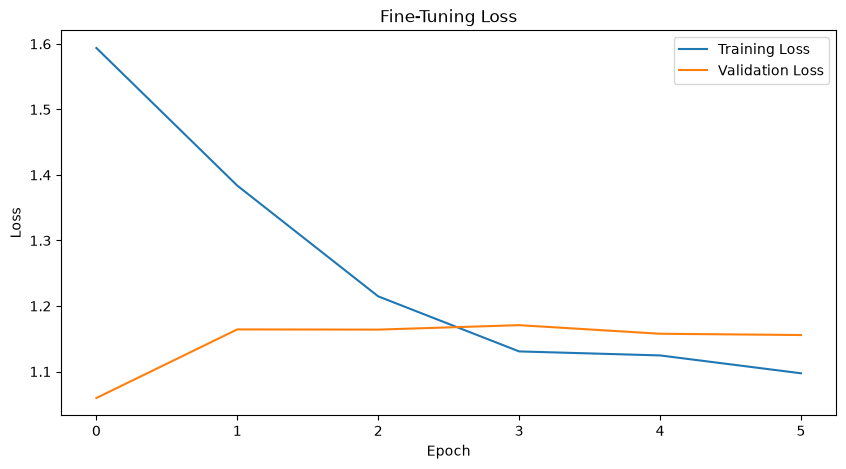

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_fine.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_fine.history["val_loss"],
    label="Validation Loss"
)

plt.title("Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Final Test Evaluation

The test dataset contains images that were not used for training or
validation.

We will now evaluate the final fine-tuned model.

In [34]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 270ms/step - accuracy: 0.6881 - loss: 1.0656
Test Loss: 1.0656
Test Accuracy: 68.81%


## Generating Predictions

To calculate detailed classification metrics, we need:

- Actual labels
- Predicted labels

The model returns probabilities for every class.

For example:

```text
airport_inside → 0.02
artstudio      → 0.01
bakery         → 0.05
bedroom        → 0.87
...

In [35]:
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated.")
print("Number of test samples:", len(y_true))

Predictions generated.
Number of test samples: 1340


## Classification Report

Accuracy gives us a single overall score.

A classification report gives us more detailed information for every class:

- Precision
- Recall
- F1-score
- Support

This is useful because some classes may be easier to classify than others.

In [36]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    zero_division=0
)

print(report)

                     precision    recall  f1-score   support

     airport_inside       0.73      0.55      0.63        20
          artstudio       0.62      0.50      0.56        20
         auditorium       0.53      0.56      0.54        18
             bakery       0.63      0.63      0.63        19
                bar       0.39      0.50      0.44        18
           bathroom       0.65      0.94      0.77        18
            bedroom       0.56      0.67      0.61        21
          bookstore       0.68      0.75      0.71        20
            bowling       0.95      0.90      0.92        20
             buffet       0.73      0.95      0.83        20
             casino       0.94      0.84      0.89        19
      children_room       0.50      0.33      0.40        18
      church_inside       0.80      0.84      0.82        19
          classroom       0.72      0.72      0.72        18
           cloister       0.83      1.00      0.91        20
             closet    

## Visualizing Model Predictions

Numbers and metrics are important, but it is also useful to visually inspect
the model's predictions.

We will display test images together with:

- Actual class
- Predicted class
- Confidence

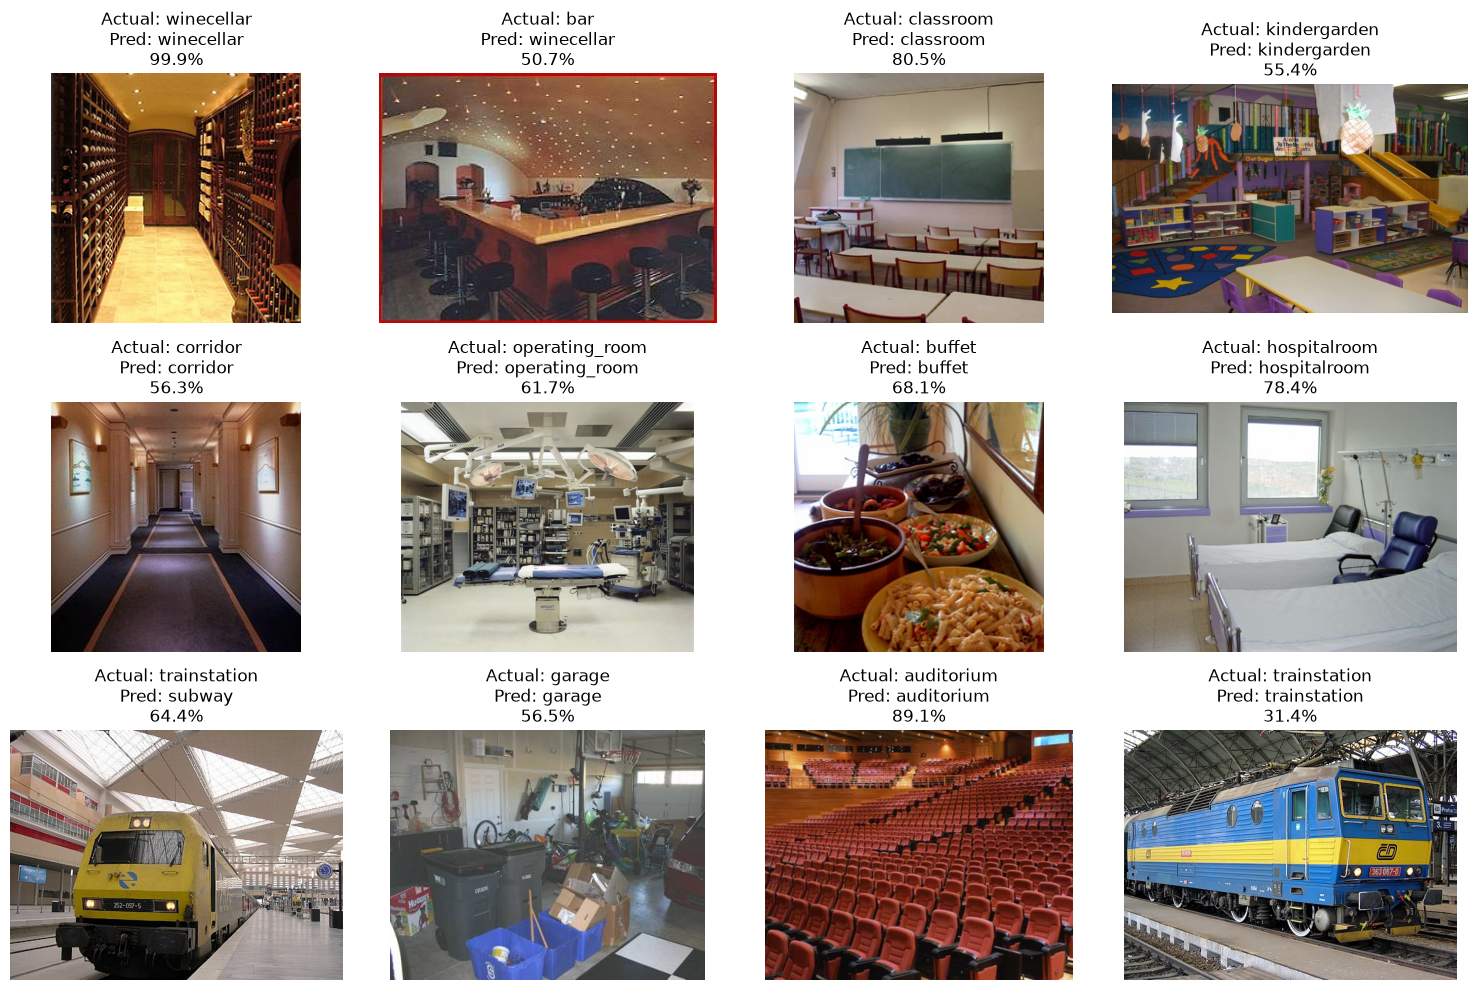

In [37]:
# Show predictions for sample test images

sample_df = test_df.sample(
    12,
    random_state=42
)

plt.figure(figsize=(15, 10))

for i, (_, row) in enumerate(sample_df.iterrows()):

    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    image_resized = image.resize(IMG_SIZE)

    image_array = np.array(
        image_resized,
        dtype=np.float32
    )

    image_batch = np.expand_dims(
        image_array,
        axis=0
    )

    prediction = model.predict(
        image_batch,
        verbose=0
    )[0]

    predicted_index = np.argmax(prediction)

    predicted_class = index_to_class[
        predicted_index
    ]

    confidence = prediction[
        predicted_index
    ] * 100

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {row['class_name']}\n"
        f"Pred: {predicted_class}\n"
        f"{confidence:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Top-5 Predictions

Instead of showing only one prediction, we can display the five classes with
the highest predicted probabilities.

This is especially useful for difficult indoor scenes where several classes
may look visually similar.

In [38]:
def predict_top5(image_file):

    image = Image.open(
        image_file
    ).convert("RGB")

    image_resized = image.resize(
        IMG_SIZE
    )

    image_array = np.array(
        image_resized,
        dtype=np.float32
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    top_indices = np.argsort(
        probabilities
    )[-5:][::-1]

    results = []

    for index in top_indices:

        results.append({
            "Class": index_to_class[index],
            "Probability": probabilities[index]
        })

    return pd.DataFrame(results)

In [39]:
# Test Top-5 prediction

sample_image = test_df.iloc[0]["image_path"]

top5_results = predict_top5(
    sample_image
)

top5_results

,Class,Probability
0,kitchen,0.466668
1,closet,0.120296
2,garage,0.111343
3,office,0.085795
4,bedroom,0.056761


## Single Image Prediction

We can now create a reusable function that accepts any image and predicts
its indoor scene category.

In [40]:
def predict_image(image_file):

    image = Image.open(
        image_file
    ).convert("RGB")

    image_resized = image.resize(
        IMG_SIZE
    )

    image_array = np.array(
        image_resized,
        dtype=np.float32
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        probabilities
    )

    predicted_class = index_to_class[
        predicted_index
    ]

    confidence = probabilities[
        predicted_index
    ]

    return predicted_class, confidence

In [41]:
# Example prediction

sample_image = test_df.iloc[0]["image_path"]

predicted_class, confidence = predict_image(
    sample_image
)

print("Predicted Class:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")

Predicted Class: kitchen
Confidence: 46.67%


## Saving the Final Model

After training and evaluation, we save the trained model.

The `.keras` format stores the model architecture and learned weights.

This allows us to load the model later without training it again.

In [42]:
model.save(
    "indoor_scene_efficientnet_final.keras"
)

print("Model saved successfully.")

Model saved successfully.


In [44]:
import json

with open("class_names.json", "w") as f:
    json.dump(classes, f, indent=4)

print("Class names saved successfully.")
print("Number of classes:", len(classes))

Class names saved successfully.
Number of classes: 67
